# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [ ]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
%pip install geemap --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='quick-bonfire-503510-q4') #<- Remember to change this to your own project's name!

In [3]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [4]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [5]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)


**Answer:** Other mathematical compositing approaches could include a mean composite where the average value of all valid observations is calculated for each pixel and band.  
Maximum composite which selects the highest observed value.
And a minimum composite which selects the lowest observed value.
Another option is a percentile composite, where chosen percentile such as 25th or 75th percentile is selected from the observations at each pixel. These methods like the current median composite reduce the filtered ImageCollection to a single image by applying the chosen statistic pixel by pixel and band by band across the image stack.


In [6]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [7]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

**Answer:** ee.Image('ESA/WorldCover/v100/2020') is the 2020 WorldCover product. The official Earth Engine catalogue states that WorldCover v100 provides a global land-cover map for 2020, based on Sentinel-1 and Sentinel-2 data.

In [8]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [9]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3156000077724457
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)


**Answer:** As per the output sample number 2 belongs to class =8 (Original WorldCover class 80 → remapped class 8) represents the Permanent water bodies land-cover class.

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [10]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [11]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [12]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [13]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

**Answer:** The **ESA WorldCover map is smoother and more generalized**, with larger continuous land-cover regions. In comparison, the **Random Forest classification is much more fragmented and speckled**, with many small patches and some noticeably different boundaries, especially around the coastline, urban areas, and vegetation. Since both layers use `randomVisualizer()`, the colours themselves should not be compared directly the spatial patterns are the important part.

These differences could be caused by several factors. The Random Forest was trained from only a sample of pixels and uses just four Sentinel-2 bands (B2, B3, B4 and B8), so some land-cover types may be difficult to separate. The Sentinel-2 composite is also from **2021**, while the ESA WorldCover map represents **2020**, so real land-cover changes may contribute.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


In [15]:
## Building comparable annual Sentinel-2 composites

# We are not using original QA60 masking here. Google documents that QA60 is masked out from 25 January 2022 through 28 February 2024, which directly affects the requested 2022 map. Using the Sentinel-2 SCL band instead gives a consistent cloud-mask method across all four years.

# Bands used by the classifier
bands = ['B2', 'B3', 'B4', 'B8']


# Cloud mask using the SCL band
# This works consistently for 2018, 2020, 2022 and 2024
def mask_s2_scl(image):
    scl = image.select('SCL')

    clear_mask = (
        scl.neq(1)
        .And(scl.neq(3))
        .And(scl.neq(7))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    return (
        image.updateMask(clear_mask)
        .select(bands)
        .divide(10000)
    )


# Building the filtered image collection for one year
def get_s2_collection(year):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(f'{year}-01-01', f'{year + 1}-01-01')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(mask_s2_scl)
    )


# Turn the collection into one annual median composite
def annual_composite(year):
    return (
        get_s2_collection(year)
        .median()
        .clip(aoi)
    )


# Useful check: make sure each year actually has imagery
for year in [2018, 2020, 2022, 2024]:
    print(
        year,
        "images:",
        get_s2_collection(year).size().getInfo()
    )

2018 images: 16
2020 images: 81
2022 images: 48
2024 images: 77


In [16]:
# Training the RF specifically on 2020

# 2020 Sentinel-2 composite
s2_2020 = annual_composite(2020)

# ESA WorldCover 2020
valid_classes = ee.List.sequence(10, 100, 10)
remap_to = ee.List.sequence(1, 10)

landcover_2020 = (
    ee.Image('ESA/WorldCover/v100/2020')
    .select('Map')
    .clip(aoi)
)

landcover_remapped = (
    landcover_2020
    .remap(valid_classes, remap_to)
    .rename('Map_remapped')
)

# Combine spectral features with class labels
training_data_2020 = s2_2020.addBands(landcover_remapped)


# Sample training pixels
sample_2020 = (
    training_data_2020
    .select(bands + ['Map_remapped'])
    .sample(
        region=aoi,
        scale=10,
        numPixels=5000,
        seed=2,
        geometries=True
    )
)


# Reproducible 70 / 20 / 10 split
sample_2020 = sample_2020.randomColumn(
    'random',
    seed=42
)

train = sample_2020.filter(
    ee.Filter.lt('random', 0.7)
)

valid = sample_2020.filter(
    ee.Filter.And(
        ee.Filter.gte('random', 0.7),
        ee.Filter.lt('random', 0.9)
    )
)

test = sample_2020.filter(
    ee.Filter.gte('random', 0.9)
)

classifier_2020 = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=100,
        seed=42
    )
    .train(
        features=train,
        classProperty='Map_remapped',
        inputProperties=bands
    )
)

In [17]:
# Calculating the actual 2020 test accuracy

# Applying classifier to the 2020 test set
test_predicted = test.classify(
    classifier_2020,
    'predicted'
)

# Test confusion matrix
test_matrix = test_predicted.errorMatrix(
    'Map_remapped',
    'predicted',
    ee.List.sequence(1, 10)
)

# Overall test accuracy
test_accuracy = test_matrix.accuracy().getInfo()

print("2020 test samples:", test.size().getInfo())
print(f"2020 RF test accuracy: {test_accuracy:.3f}")
print(f"2020 RF test accuracy: {test_accuracy * 100:.1f}%")

2020 test samples: 519
2020 RF test accuracy: 0.902
2020 RF test accuracy: 90.2%


In [18]:
# Apply that same 2020-trained RF to 2018, 2022 and 2024

years = [2018, 2022, 2024]

classified_years = {}

for year in years:

    # New Sentinel-2 data
    s2_year = annual_composite(year)

    # SAME classifier trained on 2020
    classified_years[year] = (
        s2_year
        .select(bands)
        .classify(classifier_2020)
        .rename('classification')
        .toByte()
    )

In [19]:
# Exporting the three classification rastrs

for year in years:
    geemap.ee_export_image(
        classified_years[year].unmask(0),
        filename=f'wellington_rf_{year}.tif',
        scale=10,
        crs='EPSG:2193',       # NZTM2000
        region=aoi,
        file_per_band=False
    )

Generating URL ...
Please wait ...
Data downloaded to /content/wellington_rf_2018.tif
Generating URL ...
Please wait ...
Data downloaded to /content/wellington_rf_2022.tif
Generating URL ...
Please wait ...
An error occurred while downloading.


In [20]:
# couldn't download the wellington_rf_2024. So had to take below approach to download it directly in google drive and later I dropped it in my local folder

task = ee.batch.Export.image.toDrive(
    image=classified_years[2024].unmask(0),
    description='Wellington_RF_2024',
    folder='GEOG761',
    fileNamePrefix='wellington_rf_2024',
    region=aoi,
    scale=10,
    crs='EPSG:2193',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

task.start()

print("Export task started.")

Export task started.


In [22]:
print(task.status())

{'state': 'RUNNING', 'description': 'Wellington_RF_2024', 'priority': 100, 'creation_timestamp_ms': 1787190300164, 'update_timestamp_ms': 1787190462595, 'start_timestamp_ms': 1787190304434, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 51.964, 'id': 'RGASZX5ISV56WMRUZWY3IKVF', 'name': 'projects/quick-bonfire-503510-q4/operations/RGASZX5ISV56WMRUZWY3IKVF'}


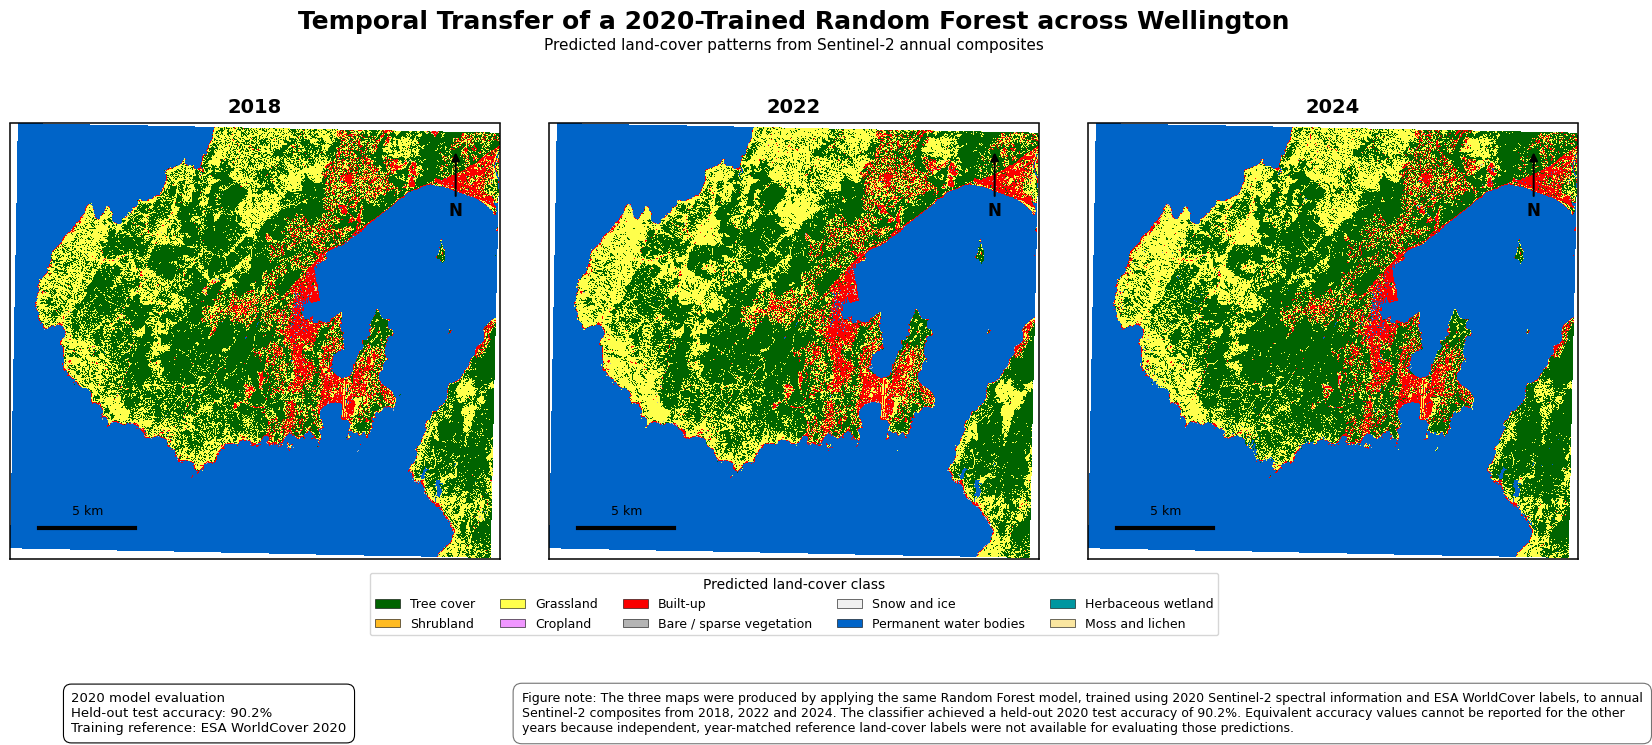

In [23]:
# producing the final figure

import numpy as np
import matplotlib.pyplot as plt
import rasterio

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Land-cover labels and fixed colours
# ---------------------------------------------------------

class_names = [
    'Tree cover',
    'Shrubland',
    'Grassland',
    'Cropland',
    'Built-up',
    'Bare / sparse vegetation',
    'Snow and ice',
    'Permanent water bodies',
    'Herbaceous wetland',
    'Moss and lichen'
]

palette = [
    '#006400',   # Tree cover
    '#ffbb22',   # Shrubland
    '#ffff4c',   # Grassland
    '#f096ff',   # Cropland
    '#fa0000',   # Built-up
    '#b4b4b4',   # Bare / sparse vegetation
    '#f0f0f0',   # Snow and ice
    '#0064c8',   # Permanent water
    '#0096a0',   # Wetland
    '#fae6a0'    # Moss and lichen
]

cmap = ListedColormap(palette)

norm = BoundaryNorm(
    np.arange(0.5, 11.5, 1),
    cmap.N
)


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def add_north_arrow(ax):

    ax.annotate(
        'N',
        xy=(0.91, 0.94),
        xytext=(0.91, 0.80),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='-|>',
            linewidth=1.5,
            color='black'
        )
    )


def add_scale_bar(ax, length_km=5):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width = xmax - xmin
    height = ymax - ymin

    x0 = xmin + 0.06 * width
    y0 = ymin + 0.07 * height

    length_m = length_km * 1000

    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],
        color='black',
        linewidth=3
    )

    ax.text(
        x0 + length_m / 2,
        y0 + 0.025 * height,
        f'{length_km} km',
        ha='center',
        va='bottom',
        fontsize=9
    )


# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

years = [2018, 2022, 2024]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 8)
)


# ---------------------------------------------------------
# Plot each classified year
# ---------------------------------------------------------

for ax, year in zip(axes, years):

    filename = f'wellington_rf_{year}.tif'

    with rasterio.open(filename) as src:

        data = src.read(1)

        # Value 0 was introduced only as export NoData
        data = np.ma.masked_equal(data, 0)

        extent = plotting_extent(src)

        ax.imshow(
            data,
            cmap=cmap,
            norm=norm,
            extent=extent,
            interpolation='nearest'
        )

    ax.set_title(
        f'{year}',
        fontsize=14,
        fontweight='bold',
        pad=8
    )

    ax.set_xticks([])
    ax.set_yticks([])

    # Give panels a visible boundary
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

    add_north_arrow(ax)
    add_scale_bar(ax, length_km=5)


# ---------------------------------------------------------
# Main title + subtitle
# ---------------------------------------------------------

fig.suptitle(
    'Temporal Transfer of a 2020-Trained Random Forest across Wellington',
    fontsize=18,
    fontweight='bold',
    y=0.975
)

fig.text(
    0.5,
    0.925,
    'Predicted land-cover patterns from Sentinel-2 annual composites',
    ha='center',
    fontsize=11
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=palette[i],
        edgecolor='black',
        linewidth=0.4,
        label=class_names[i]
    )
    for i in range(len(class_names))
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.185),
    ncol=5,
    frameon=True,
    title='Predicted land-cover class',
    fontsize=9,
    title_fontsize=10
)


# ---------------------------------------------------------
# Model performance box
# ---------------------------------------------------------

performance_text = (
    f'2020 model evaluation\n'
    f'Held-out test accuracy: {test_accuracy:.1%}\n'
    f'Training reference: ESA WorldCover 2020'
)

fig.text(
    0.075,
    0.095,
    performance_text,
    ha='left',
    va='center',
    fontsize=9.5,
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='white',
        edgecolor='black',
        linewidth=0.8
    )
)


# ---------------------------------------------------------
# Detailed figure note
# ---------------------------------------------------------

note_text = (
    'Figure note: The three maps were produced by applying the same Random Forest '
    'model, trained using 2020 Sentinel-2 spectral information and ESA WorldCover '
    'labels, to annual Sentinel-2 composites from 2018, 2022 and 2024. '
    f'The classifier achieved a held-out 2020 test accuracy of {test_accuracy:.1%}. '
    'Equivalent accuracy values cannot be reported for the other years because '
    'independent, year-matched reference land-cover labels were not available '
    'for evaluating those predictions.'
)

fig.text(
    0.34,
    0.095,
    note_text,
    ha='left',
    va='center',
    fontsize=9,
    wrap=True,
    bbox=dict(
        boxstyle='round,pad=0.7',
        facecolor='white',
        edgecolor='0.45',
        linewidth=0.8
    )
)


# ---------------------------------------------------------
# Layout and export
# ---------------------------------------------------------

plt.tight_layout(
    rect=[0.02, 0.27, 0.98, 0.90]
)

plt.savefig(
    'Q5_Wellington_RF_Temporal_Classification.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'Q5_Wellington_RF_Temporal_Classification.pdf',
    bbox_inches='tight'
)

plt.show()

# SVMs Applied to Satellite Data

In [24]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [ ]:
# Code to get you started

import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/LCDB_v5.shp") #<- Check file names
print(gdf.head())


In [33]:
# lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP file manually uploaded in content folder

import os
import glob
import zipfile
import geopandas as gpd

# --------------------------------------------------
# Location of the LCDB file/folder in Colab
# --------------------------------------------------

matches = glob.glob(
    "/content/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP*"
)

print("Found:", matches)

# --------------------------------------------------
# Find the shapefile
# --------------------------------------------------

shp_files = glob.glob(
    os.path.join(
        search_folder,
        "**",
        "*.shp"
    ),
    recursive=True
)

print("\nShapefile(s) found:")
print(shp_files)

if len(shp_files) == 0:
    raise FileNotFoundError(
        "No .shp file was found inside the LCDB data."
    )


# --------------------------------------------------
# Load the shapefile
# --------------------------------------------------

shp_path = shp_files[0]

gdf = gpd.read_file(shp_path)

print("\nLoaded shapefile:")
print(shp_path)

print("\nCRS:")
print(gdf.crs)

print("\nNumber of polygons:")
print(len(gdf))

display(gdf.head())

Found: ['/content/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP (1).zip', '/content/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip']

Shapefile(s) found:
['/content/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp']

Loaded shapefile:
/content/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp

CRS:
EPSG:2193

Number of polygons:
532


,Name_2018,Name_2012,Name_2008,Name_2001,Name_1996,Class_2018,Class_2012,Class_2008,Class_2001,Class_1996,...,Wetland_96,Onshore_18,Onshore_12,Onshore_08,Onshore_01,Onshore_96,EditAuthor,EditDate,LCDB_UID,geometry
0,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168553,"POLYGON ((1820024.88 6001115.814, 1820021.712 ..."
1,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,10,10,10,10,10,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000009545,"POLYGON ((1820054.749 6001263.521, 1820067.563..."
2,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168544,"POLYGON ((1818892.667 6000858.715, 1818932.048..."
3,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,Sand or Gravel,10,10,10,10,10,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000009547,"POLYGON ((1818879.751 6001641.58, 1818900.374 ..."
4,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,Indigenous Forest,69,69,69,69,69,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb1000168423,"POLYGON ((1819193.973 5997373.55, 1819165.748 ..."


In [31]:
classes_2018 = (
    gdf[
        ['Class_2018', 'Name_2018']
    ]
    .drop_duplicates()
    .sort_values('Class_2018')
)

display(classes_2018)

,Class_2018,Name_2018
40,1,Built-up Area (settlement)
171,2,Urban Parkland/Open Space
423,5,Transport Infrastructure
48,6,Surface Mine or Dump
1,10,Sand or Gravel
307,12,Landslide
140,16,Gravel or Rock
256,20,Lake or Pond
139,21,River
174,22,Estuarine Open Water


In [34]:
# Remove any polygons without a 2018 class
gdf = gdf.dropna(subset=['Class_2018']).copy()

# Make sure class codes are integers
gdf['Class_2018'] = gdf['Class_2018'].astype(int)


# Create a clean lookup table of the classes
class_table = (
    gdf[['Class_2018', 'Name_2018']]
    .drop_duplicates(subset=['Class_2018'])
    .sort_values('Class_2018')
    .reset_index(drop=True)
)


# Create sequential machine-learning labels:
# 0, 1, 2, 3, ...
class_table['label'] = range(len(class_table))

display(class_table)

,Class_2018,Name_2018,label
0,1,Built-up Area (settlement),0
1,2,Urban Parkland/Open Space,1
2,5,Transport Infrastructure,2
3,6,Surface Mine or Dump,3
4,10,Sand or Gravel,4
5,12,Landslide,5
6,16,Gravel or Rock,6
7,20,Lake or Pond,7
8,21,River,8
9,22,Estuarine Open Water,9


In [38]:
# Mapping:
# original LCDB code -> sequential ML label

class_to_label = dict(
    zip(
        class_table['Class_2018'],
        class_table['label']
    )
)

print("Class mapping:")
print(class_to_label)

# Add label column to GeoDataFrame
gdf['label'] = (
    gdf['Class_2018']
    .map(class_to_label)
    .astype(int)
)

display(
    gdf[['Class_2018', 'Name_2018', 'label']].head(10)
)

Class mapping:
{1: 0, 2: 1, 5: 2, 6: 3, 10: 4, 12: 5, 16: 6, 20: 7, 21: 8, 22: 9, 33: 10, 40: 11, 41: 12, 45: 13, 46: 14, 51: 15, 52: 16, 54: 17, 64: 18, 69: 19, 70: 20, 71: 21}


,Class_2018,Name_2018,label
0,69,Indigenous Forest,19
1,10,Sand or Gravel,4
2,69,Indigenous Forest,19
3,10,Sand or Gravel,4
4,69,Indigenous Forest,19
5,10,Sand or Gravel,4
6,69,Indigenous Forest,19
7,51,Gorse and/or Broom,15
8,52,Manuka and/or Kanuka,16
9,69,Indigenous Forest,19


In [40]:
# Convert shapefile CRS to WGS84
gdf_wgs84 = gdf.to_crs(epsg=4326)

# Convert GeoDataFrame -> Earth Engine FeatureCollection
lcdb_fc = geemap.gdf_to_ee(gdf_wgs84)

print(
    "Number of LCDB polygons:",
    lcdb_fc.size().getInfo()
)

# AOI based on the extent of the downloaded Great Barrier data
aoi_gbi = lcdb_fc.geometry().bounds()

Number of LCDB polygons: 532


In [41]:
Map = geemap.Map()

Map.centerObject(aoi_gbi, 10)

Map.addLayer(
    lcdb_fc.style(
        color='yellow',
        fillColor='00000000',
        width=1
    ),
    {},
    'LCDB 2018'
)

Map

Map(center=[-36.18707388906557, 175.4164047076836], controls=(WidgetControl(options=['position', 'transparent_…

In [42]:
bands = ['B2', 'B3', 'B4', 'B8']


def mask_s2_scl(image):

    scl = image.select('SCL')

    # Remove bad pixels, cloud shadows, clouds,
    # cirrus and snow/ice
    clear_mask = (
        scl.neq(1)
        .And(scl.neq(3))
        .And(scl.neq(7))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    return (
        image
        .updateMask(clear_mask)
        .select(bands)
        .divide(10000)
    )

In [43]:
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_gbi)
    .filterDate('2018-12-01', '2019-03-01')
    .filter(
        ee.Filter.lt(
            'CLOUDY_PIXEL_PERCENTAGE',
            20
        )
    )
    .map(mask_s2_scl)
)

print(
    "Number of Sentinel-2 images:",
    s2_collection.size().getInfo()
)

Number of Sentinel-2 images: 28


In [44]:
s2_gbi = (
    s2_collection
    .median()
    .clip(aoi_gbi)
)

print("Summer 2018/19 Sentinel-2 composite created.")

Summer 2018/19 Sentinel-2 composite created.


In [ ]:
Map = geemap.Map()

Map.centerObject(aoi_gbi, 10)

Map.addLayer(
    s2_gbi,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0.02,
        'max': 0.30
    },
    'Sentinel-2 True Colour'
)

Map.addLayer(
    lcdb_fc.style(
        color='yellow',
        fillColor='00000000',
        width=1
    ),
    {},
    'LCDB boundaries',
    False
)

Map

In [ ]:
label_img = (
    lcdb_fc
    .reduceToImage(
        properties=['label'],
        reducer=ee.Reducer.first()
    )
    .rename('label')
    .toInt16()
)

print("LCDB polygons converted to raster labels.")

In [ ]:
training_image = (
    s2_gbi
    .addBands(label_img)
)

In [ ]:
sample_gbi = (
    training_image
    .stratifiedSample(
        numPoints=200,
        classBand='label',
        region=aoi_gbi,
        scale=10,
        seed=2,
        geometries=True
    )
)

print(
    "Total sampled pixels:",
    sample_gbi.size().getInfo()
)

In [ ]:
class_counts = (
    sample_gbi
    .reduceColumns(
        reducer=ee.Reducer.frequencyHistogram(),
        selectors=['label']
    )
)

print("Number of samples per class:")
print(class_counts.getInfo())

In [ ]:
sample_gbi = (
    sample_gbi
    .randomColumn(
        columnName='random',
        seed=42
    )
)

train_gbi = sample_gbi.filter(
    ee.Filter.lt('random', 0.7)
)

valid_gbi = sample_gbi.filter(
    ee.Filter.And(
        ee.Filter.gte('random', 0.7),
        ee.Filter.lt('random', 0.9)
    )
)

test_gbi = sample_gbi.filter(
    ee.Filter.gte('random', 0.9)
)

print("Training samples:",
      train_gbi.size().getInfo())

print("Validation samples:",
      valid_gbi.size().getInfo())

print("Test samples:",
      test_gbi.size().getInfo())

In [ ]:
svm_gbi = (
    ee.Classifier.libsvm(
        kernelType='RBF',
        gamma=0.5,
        cost=10
    )
    .train(
        features=train_gbi,
        classProperty='label',
        inputProperties=bands
    )
)

print("SVM training completed.")

In [ ]:
validated_gbi = (
    valid_gbi
    .classify(
        svm_gbi,
        'predicted'
    )
)

validation_matrix = (
    validated_gbi
    .errorMatrix(
        'label',
        'predicted'
    )
)

validation_accuracy = (
    validation_matrix
    .accuracy()
    .getInfo()
)

print(
    f"Validation accuracy: "
    f"{validation_accuracy:.1%}"
)

print("\nValidation confusion matrix:")
print(validation_matrix.getInfo())

In [ ]:
test_pred = (
    test_gbi
    .classify(
        svm_gbi,
        'predicted'
    )
)

test_matrix = (
    test_pred
    .errorMatrix(
        'label',
        'predicted'
    )
)

test_accuracy = (
    test_matrix
    .accuracy()
    .getInfo()
)

print("\nTest confusion matrix:")
print(test_matrix.getInfo())

print(
    f"\nHeld-out test accuracy: "
    f"{test_accuracy:.1%}"
)

In [ ]:
from sklearn.metrics import (
    f1_score,
    classification_report
)

# Download the test predictions to Python
y_true = (
    test_pred
    .aggregate_array('label')
    .getInfo()
)

y_pred = (
    test_pred
    .aggregate_array('predicted')
    .getInfo()
)

# Macro-average F1
macro_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

print(
    f"Macro F1 score: "
    f"{macro_f1:.3f}"
)

In [ ]:
label_to_name = dict(
    zip(
        class_table['label'],
        class_table['Name_2018']
    )
)

present_labels = sorted(
    set(y_true) | set(y_pred)
)

target_names = [
    str(label_to_name[x])
    for x in present_labels
]

print(
    classification_report(
        y_true,
        y_pred,
        labels=present_labels,
        target_names=target_names,
        zero_division=0
    )
)

In [ ]:
classified_gbi = (
    s2_gbi
    .select(bands)
    .classify(svm_gbi)
    .rename('classification')
)

# Mask everything outside the LCDB mapped area
classified_gbi = (
    classified_gbi
    .updateMask(
        label_img.mask()
    )
)

print("Great Barrier classification completed.")

In [ ]:
Map = geemap.Map()

Map.centerObject(
    aoi_gbi,
    10
)

Map.addLayer(
    classified_gbi.randomVisualizer(),
    {},
    'SVM classification'
)

Map.addLayer(
    lcdb_fc.style(
        color='black',
        fillColor='00000000',
        width=1
    ),
    {},
    'LCDB polygons',
    False
)

Map

In [ ]:
nztm = ee.Projection(
    'EPSG:2193'
)

aoi_nztm = (
    aoi_gbi
    .bounds(
        maxError=1,
        proj=nztm
    )
)

In [ ]:
classified_export = (
    classified_gbi
    .unmask(255)
    .toByte()
)

In [ ]:
output_tif = (
    '/content/'
    'great_barrier_svm_2018.tif'
)

geemap.ee_export_image(
    classified_export,
    filename=output_tif,
    scale=10,
    crs='EPSG:2193',
    region=aoi_nztm,
    file_per_band=False,
    timeout=900
)

In [ ]:
import os

print(
    "File exists:",
    os.path.exists(output_tif)
)

print(output_tif)

In [ ]:
import rasterio

from rasterio.plot import plotting_extent

with rasterio.open(output_tif) as src:

    classified_array = src.read(1)

    raster_extent = plotting_extent(src)

    print("CRS:", src.crs)
    print("Shape:", classified_array.shape)

In [ ]:
classified_array = np.ma.masked_equal(
    classified_array,
    255
)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [ ]:
base_colors = (
    list(plt.cm.tab20.colors)
    + list(plt.cm.Set3.colors)
)

class_colors = base_colors[
    :len(class_table)
]

cmap = ListedColormap(
    class_colors
)

boundaries = np.arange(
    -0.5,
    len(class_table) + 0.5,
    1
)

norm = BoundaryNorm(
    boundaries,
    cmap.N
)

In [ ]:
legend_handles = []

for _, row in class_table.iterrows():

    label_id = int(row['label'])
    class_name = row['Name_2018']

    legend_handles.append(
        Patch(
            facecolor=class_colors[label_id],
            edgecolor='black',
            linewidth=0.4,
            label=class_name
        )
    )

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


fig, ax = plt.subplots(
    figsize=(12, 12)
)


# ------------------------------------------------
# LAND-COVER RASTER
# ------------------------------------------------

ax.imshow(
    classified_array,
    cmap=cmap,
    norm=norm,
    extent=raster_extent,
    interpolation='nearest'
)


# ------------------------------------------------
# TITLE
# ------------------------------------------------

ax.set_title(
    "SVM-Derived Land-Cover Classification of "
    "Aotea / Great Barrier Island\n"
    "Austral Summer 2018–19",
    fontsize=17,
    fontweight='bold',
    pad=18
)


# ------------------------------------------------
# AXIS LABELS
# ------------------------------------------------

ax.set_xlabel(
    "NZTM Easting (m)",
    fontsize=10
)

ax.set_ylabel(
    "NZTM Northing (m)",
    fontsize=10
)


# ------------------------------------------------
# NORTH ARROW
# ------------------------------------------------

ax.annotate(
    'N',
    xy=(0.93, 0.92),
    xytext=(0.93, 0.82),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=1.8
    )
)


# ------------------------------------------------
# SCALE BAR — 5 km
# ------------------------------------------------

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

scale_length = 5000   # metres

scale_x = (
    x_min +
    0.07 * (x_max - x_min)
)

scale_y = (
    y_min +
    0.06 * (y_max - y_min)
)

ax.plot(
    [scale_x, scale_x + scale_length],
    [scale_y, scale_y],
    linewidth=4,
    solid_capstyle='butt'
)

ax.text(
    scale_x + scale_length / 2,
    scale_y + 0.015 * (y_max - y_min),
    '5 km',
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold'
)


# ------------------------------------------------
# MODEL PERFORMANCE BOX
# ------------------------------------------------

performance_text = (
    "SVM model performance\n"
    f"Held-out test accuracy: {test_accuracy:.1%}\n"
    f"Macro F1: {macro_f1:.3f}\n"
    "Predictors: B2, B3, B4, B8"
)

ax.text(
    0.03,
    0.97,
    performance_text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='white',
        alpha=0.90
    )
)


# ------------------------------------------------
# LEGEND
# ------------------------------------------------

ax.legend(
    handles=legend_handles,
    title="LCDB 2018 Land-Cover Classes",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    title_fontsize=9,
    frameon=True
)


# ------------------------------------------------
# FIGURE NOTE / ATTRIBUTION
# ------------------------------------------------

fig.text(
    0.10,
    0.015,
    "Classification produced with an RBF Support Vector Machine "
    "using Sentinel-2 Surface Reflectance imagery from "
    "December 2018–February 2019. Reference labels: "
    "LCDB v5.0 (2018 land-cover epoch), Manaaki Whenua – "
    "Landcare Research / LRIS Portal. "
    "Sentinel-2 imagery: Copernicus / ESA, accessed through "
    "Google Earth Engine.",
    ha='left',
    va='bottom',
    fontsize=8,
    wrap=True
)


plt.tight_layout(
    rect=[0, 0.06, 0.78, 1]
)

plt.show()

In [ ]:
figure_png = (
    '/content/'
    'great_barrier_svm_landcover_2018.png'
)

figure_pdf = (
    '/content/'
    'great_barrier_svm_landcover_2018.pdf'
)

fig.savefig(
    figure_png,
    dpi=300,
    bbox_inches='tight'
)

fig.savefig(
    figure_pdf,
    bbox_inches='tight'
)

print("Saved:")
print(figure_png)
print(figure_pdf)